In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.preprocessing import LabelBinarizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
from bs4 import BeautifulSoup
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
true = pd.read_excel('/content/True.xlsx')
false = pd.read_excel('/content/Fake.xlsx')

In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29


In [ ]:
false.head()

,title,text,subject,date,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,Trump Is So Obsessed He Even Has Obamaâ€™s Na...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [ ]:
true['Category'] = 1
false['Category'] = 0
df = pd.concat([true, false])

In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,21
date,21
Category,0
...,...
Unnamed: 167,44917
Unnamed: 168,44917
Unnamed: 169,44917
Unnamed: 170,44917


In [ ]:
from bs4 import MarkupResemblesLocatorWarning
import warnings
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

def clean_text(text):
  text = BeautifulSoup(text, "html.parser").get_text()
  text = re.sub(r'http\S+', '', text)
  stop = set(stopwords.words('english'))
  punctuation = list(string.punctuation)
  stop.update(punctuation)
  final_text=[]
  for word in text.split():
    if word.strip().lower() not in stop:
      final_text.append(word.strip())
  cleaned_text = " ".join(final_text)
  if not cleaned_text:
    cleaned_text = "placeholder"
  return cleaned_text

df['clean_text'] = df['text'].apply(clean_text)

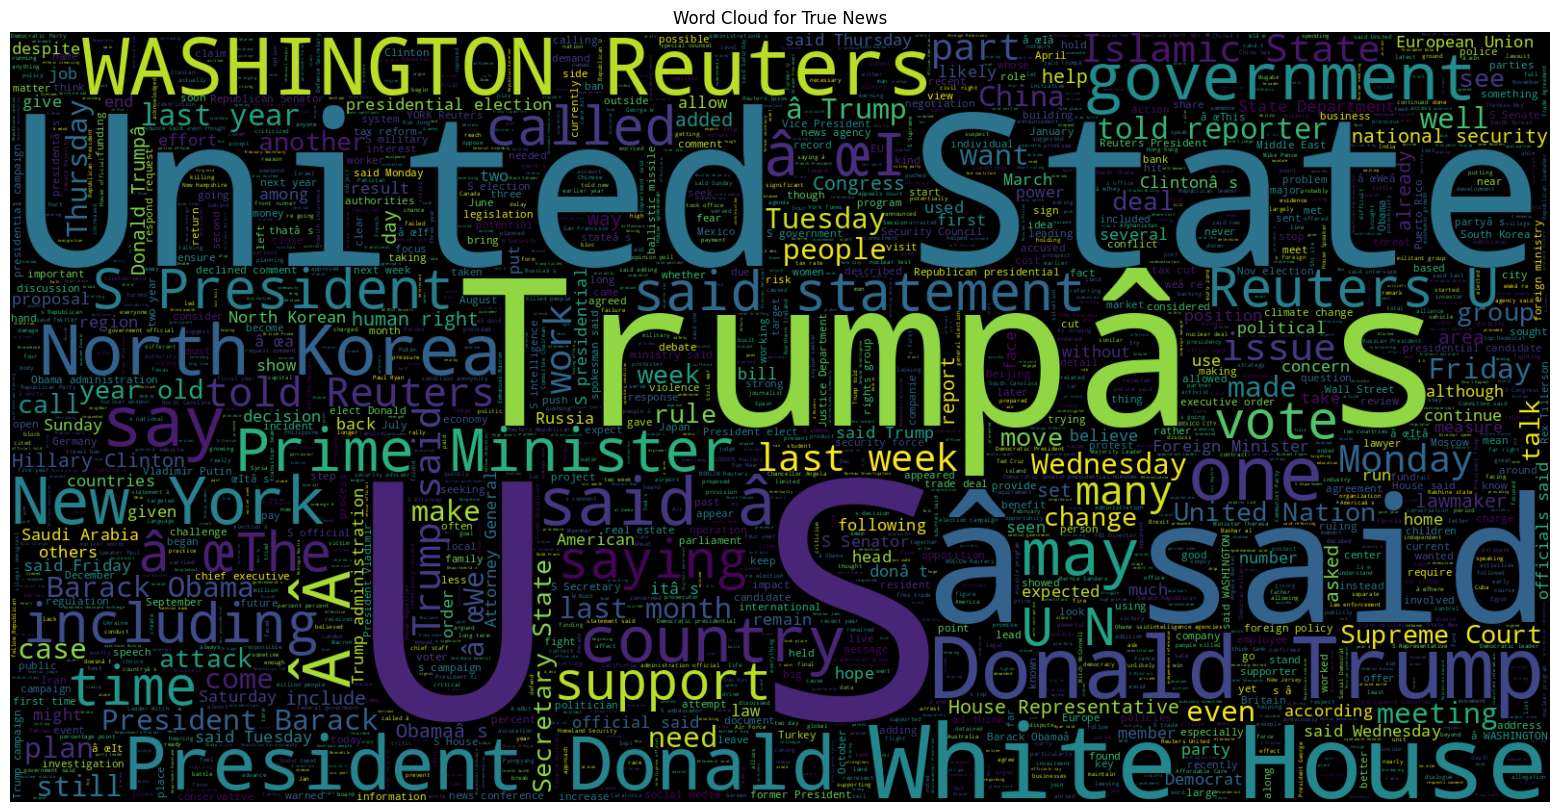

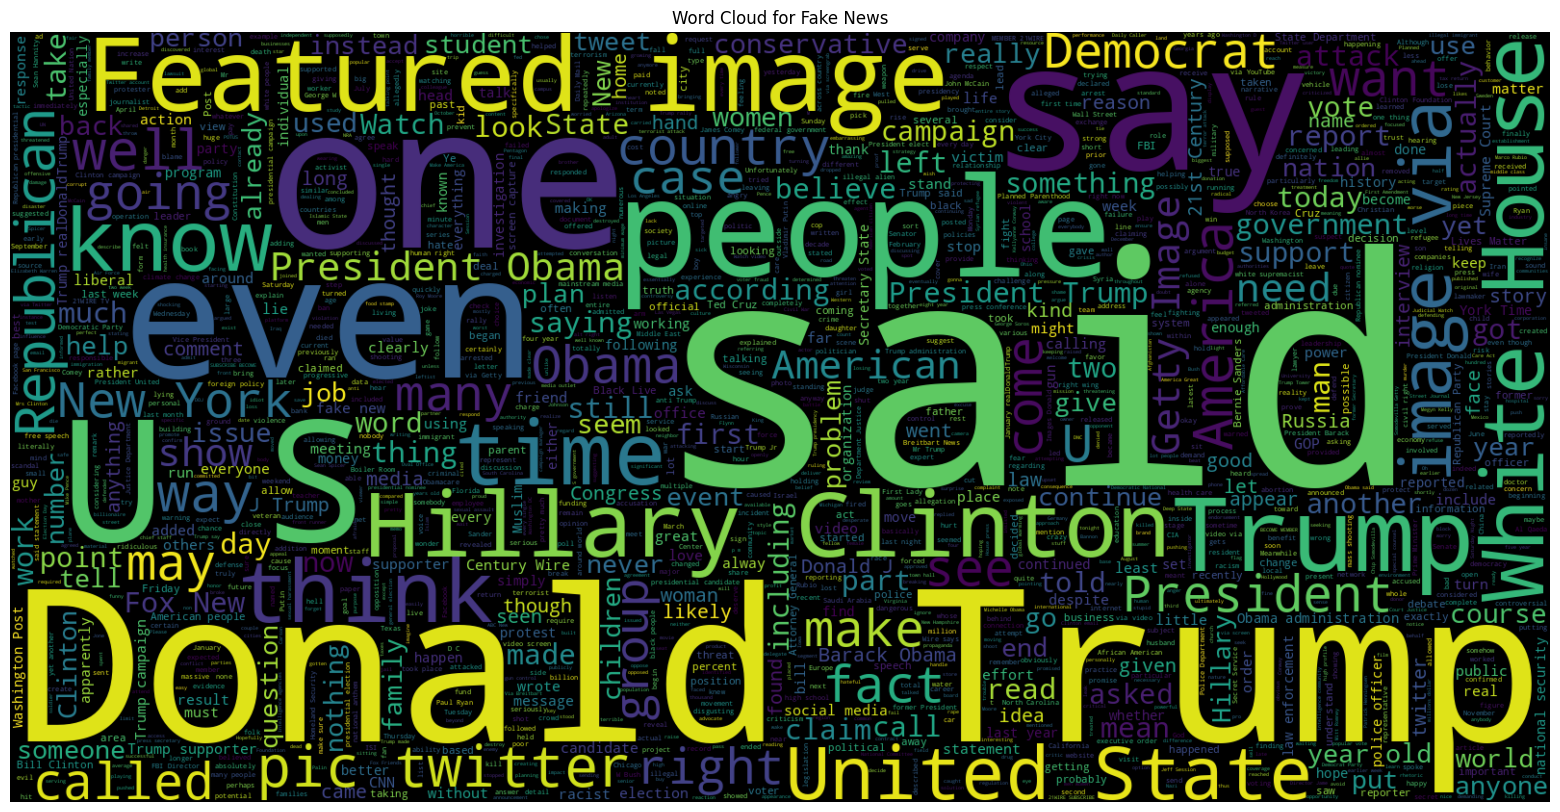

In [ ]:
def plot_wordcloud(category):
  wc = WordCloud(width=1600, height=800, max_words=2000, stopwords=STOPWORDS).generate(" ".join(df[df.Category == category].clean_text))
  plt.figure(figsize=(20,10))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(f"Word Cloud for {'True' if category == 1 else 'Fake'} News")
  plt.show()

plot_wordcloud(1)
plot_wordcloud(0)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.clean_text, df.Category, random_state=0)

In [ ]:
max_features = 10000
maxlen = 300
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(x_train)
tokenized_train = tokenizer.texts_to_sequences(x_train)
x_train = pad_sequences(tokenized_train, maxlen=maxlen)
tokenized_text = tokenizer.texts_to_sequences(x_test)
x_test = pad_sequences(tokenized_text, maxlen=maxlen)

In [ ]:
def get_coefs(word, *arr):
  return word, np.asarray(arr, dtype='float32')

EMBEDDING_FILE = "/content/glove.twitter.27B.100d.txt"

def load_embeddings(embedding_file, word_index, max_features):
  embeddings_index = dict(get_coefs(*o.rstrip().rsplit(' ')) for o in open(embedding_file, encoding='utf8'))
  all_embs = np.stack(list(embeddings_index.values()))
  emb_mean, emb_std = all_embs.mean(), all_embs.std()
  embed_size = all_embs.shape[1]

  nb_words = min(max_features, len(word_index))
  embedding_matrix = np.random.normal(emb_mean, emb_std, (nb_words, embed_size))
  for word, i in word_index.items():
    if i>=max_features:
      continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
      embedding_matrix[i] = embedding_vector
  return embedding_matrix, embed_size

embedding_matrix, embed_size = load_embeddings(EMBEDDING_FILE, tokenizer.word_index, max_features)

In [ ]:
batch_size = 256
epochs = 3
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)

model = Sequential()
model.add(Embedding(
    max_features,
    output_dim=embed_size,
    weights=[embedding_matrix],
    trainable=False
))
model.add(LSTM(
    units=128,
    return_sequences=True,
    recurrent_dropout=0.25,
    dropout=0.25
))
model.add(LSTM(
    units=64,
    recurrent_dropout=0.1,
    dropout=0.1
))
model.add(Dense(
    units=32,
    activation='relu'
))
model.add(Dense(
    units=1,
    activation='sigmoid'
))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
    callbacks=[learning_rate_reduction]
)

Epoch 1/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 731s 5s/step - accuracy: 0.8963 - loss: 0.2508 - val_accuracy: 0.9622 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 2/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 574s 4s/step - accuracy: 0.9546 - loss: 0.1259 - val_accuracy: 0.9795 - val_loss: 0.0652 - learning_rate: 0.0010
Epoch 3/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.9684 - loss: 0.0875 - val_accuracy: 0.9855 - val_loss: 0.0428 - learning_rate: 0.0010


In [ ]:
print ("Accuracy on Training Data:", model.evaluate(x_train, y_train)[1] * 100, "%")
print ("Accuracy on Testing Data:", model.evaluate(x_test, y_test)[1] * 100, "%")

1053/1053 ━━━━━━━━━━━━━━━━━━━━ 190s 181ms/step - accuracy: 0.9865 - loss: 0.0406
Accuracy on Training Data: 98.65238070487976 %
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9855 - loss: 0.0428
Accuracy on Testing Data: 98.5485315322876 %


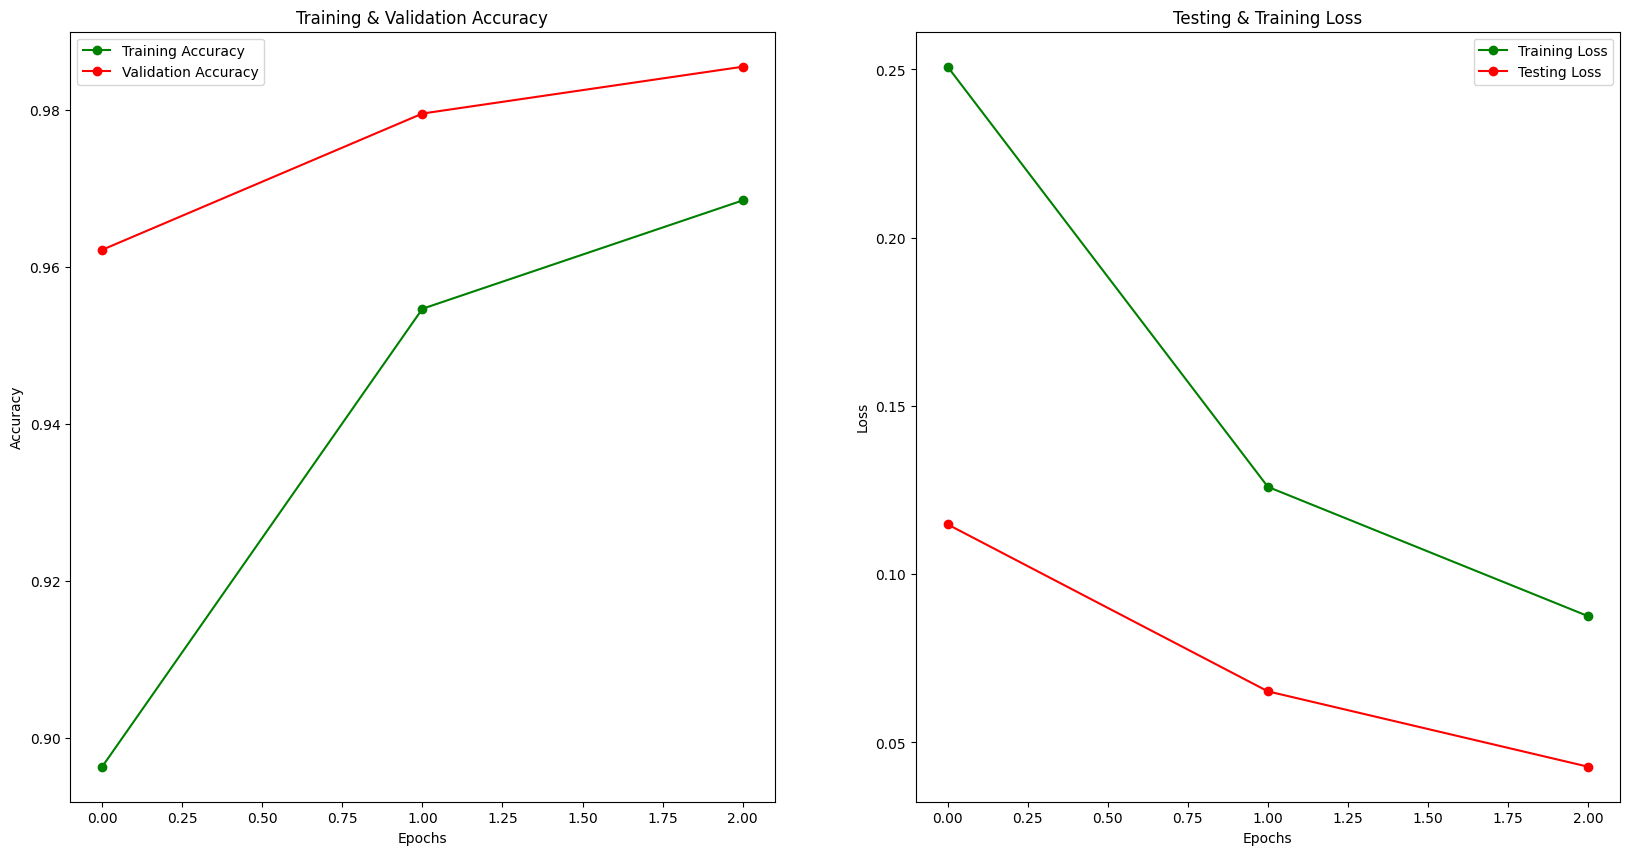

In [ ]:
actual_epochs = len(history.history['accuracy'])

epochs = [i for i in range(actual_epochs)]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20, 10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Testing Loss')
ax[1].set_title('Testing & Training Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 200ms/step
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      5853
        True       0.98      0.99      0.98      5377

    accuracy                           0.99     11230
   macro avg       0.99      0.99      0.99     11230
weighted avg       0.99      0.99      0.99     11230



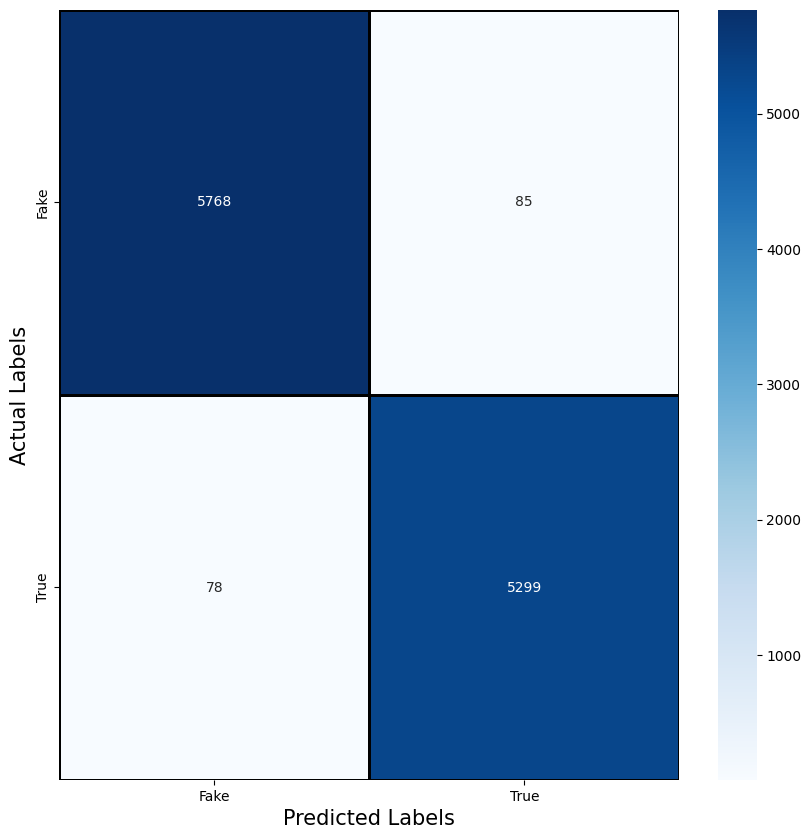

In [ ]:
pred_probabilities = model.predict(x_test)
pred = (pred_probabilities > 0.5).astype('int32')
print(classification_report(y_test, pred, target_names=['Fake', 'Not Fake']))
cm = confusion_matrix(y_test, pred)
cm = pd.DataFrame(cm, index=['Fake', 'Original'], columns=['Fake', 'Original'])

plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap='Blues', linecolor='black', linewidth=1, annot=True, fmt='', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
plt.xlabel('Predicted Labels', size=15)
plt.ylabel('Actual Labels', size=15)
plt.show()